In [2]:
import numpy as np
import pandas as pd
import tqdm
import os
import matplotlib.pyplot as plt

In [3]:
# Parameters
N = 0.44 * 1e12  # Number of atoms
q = 0.198        # Parameter
T2 = 0.87 * 1e-3  # Relaxation time in s
g_D = 0.00177    # [pA]
Sph = 96         # Photon noise PSD [pA^2/Hz]
w0 = 2 * np.pi * 1e4  # Mean value of the Larmor in OU process
w01 = w0 * T2  # in non dimensional units
h = 5 * 1e-6    # Time step is the solver time step not the probing time!whath out
tf = 2.        # Final time in [ms]
nsteps = int(tf * 1e-3 / h)  # Number of steps in simulation
h1 = h / T2      # Time step in non-dimensional units
measure_every_nth = 1
meas_probing_rate = h*measure_every_nth  # in s
#TRANSFORM DATA - compute coefficients
Nq = N * q
xc = np.sqrt(2 / Nq)
yc = np.sqrt(2 / (g_D**2 * Nq))
sig_v = np.sqrt(2 * Sph / (g_D**2 * Nq * meas_probing_rate))
meas_probing_rate_unitless = meas_probing_rate/T2

# Time constant of the OU process in non-dimensional units

xc2 = xc*xc
sgv2 = sig_v**2  # measurement noise variance

# Time vector in [ms] simulation
t = np.arange(0, tf/(T2*1e3), h1)
t_meas = np.arange(0, tf/(T2*1e3), meas_probing_rate_unitless)

# Initial condition (simulation)
x = np.array([0, np.sqrt(2 / (q * N)) * 0.5 * N, w0 * T2])


In [4]:
# SIMULATION
def step(x0, t):
    exp_t = np.exp(-t)
    cos_x2t = np.cos(x0[2] * t)
    sin_x2t = np.sin(x0[2] * t)

    x0_t = exp_t * (cos_x2t * x0[0] + sin_x2t * x0[1])
    x1_t = exp_t * (cos_x2t * x0[1] - sin_x2t * x0[0])
    x2_t = x0[2]  # Constant

    return np.array([x0_t, x1_t, x2_t])

def simulate(t_max, dt, x0, xs):
    time_arr = np.arange(0, t_max, dt)
    for index, time in enumerate(tqdm.tqdm(time_arr, desc='pid:%r' % os.getpid())):
        # SIMULATION AND MEASUREMENT==============================
        x = step(x0, dt)
        xs[index] = x
        x0 = x
    return xs


In [5]:
time_arr_sim_unitless = np.arange(0, tf/(T2*1e3), h1)
xs = np.array([np.zeros_like(x) for _ in time_arr_sim_unitless])
simulate(tf/(T2*1e3), h1, x, xs)

pid:20492: 100%|██████████| 401/401 [00:00<?, ?it/s]


array([[ 3.23865856e+05,  9.96756613e+05,  5.46637122e+01],
       [ 6.12499220e+05,  8.43032853e+05,  5.46637122e+01],
       [ 8.38201732e+05,  6.08989205e+05,  5.46637122e+01],
       ...,
       [-3.28835681e+04,  1.01205216e+05,  5.46637122e+01],
       [-4.25012875e-09,  1.05803644e+05,  5.46637122e+01],
       [ 3.25077600e+04,  1.00048598e+05,  5.46637122e+01]])

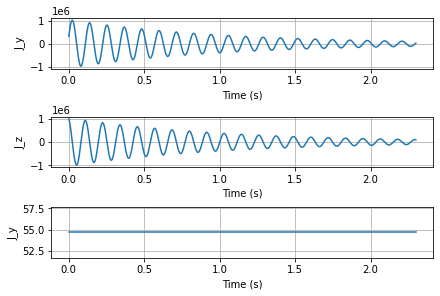

In [6]:
#Plot simulation
fig, axs = plt.subplots(3, 1, layout='constrained')
axs[0].plot(time_arr_sim_unitless, xs[:,0], label="J_y")
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('J_y')
axs[0].grid(True)

axs[1].plot(time_arr_sim_unitless, xs[:,1], label="J_z")
axs[1].set_xlabel('Time (s)')
axs[1].set_ylabel('J_z')
axs[1].grid(True)

axs[2].plot(time_arr_sim_unitless, xs[:,2], label="J_y")
axs[2].set_xlabel('Time (s)')
axs[2].set_ylabel('J_y')
axs[2].grid(True)

In [7]:
yh = []
x_sim_meas_freq = []
for idx, x1_val in enumerate(xs[:, 1]):
    if idx % measure_every_nth == 0:  # Collect every nth sample
        yh.append(x1_val + sig_v * np.random.randn())  # Add noise to the measurement
        x_sim_meas_freq.append(xs[idx,:])


t = np.arange(0, len(xs[:, 2])) * h1
t_meas = np.arange(0, len(yh)) * meas_probing_rate_unitless

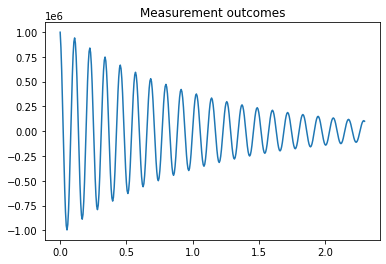

In [8]:
plt.plot(t_meas, yh)
plt.title("Measurement outcomes")
plt.show()

In [9]:
# def estimate_omega_LS(y, Delta):
#     y = np.array(y)
#     omega_estimates = []
#     time_LS = []
# 
#     for k in range(3, len(y)):
#         numerator_minus = np.sum(y[2:k] * y[1:k-1])
#         numerator_plus = np.sum(y[:k-2] * y[1:k-1])
#         denominator = 2 * np.sum(y[1:k-1]**2)
# 
#         r_minus = numerator_minus / denominator
#         r_plus = numerator_plus / denominator
# 
#         omega_hat = (1/(Delta)) * np.arccos(np.exp(Delta) * r_minus + np.exp(-Delta) * r_plus)
#         omega_estimates.append(omega_hat)
#         time_LS.append(k*h1)
#     return omega_estimates

In [16]:
def estimate_omega_LS(y, Delta, w_true):
    y = np.array(y)
    omega_sum = np.zeros(len(y) - 3)
    error_sum = np.zeros(len(y) - 3)
    count = np.zeros(len(y) - 3)

    for _ in range(1000):  # Run 1000 trials
        noisy_y = y + sig_v * np.random.randn(len(y))

        for k in range(3, len(noisy_y)):
            numerator_minus = np.sum(noisy_y[2:k] * noisy_y[1:k-1])
            numerator_plus = np.sum(noisy_y[:k-2] * noisy_y[1:k-1])
            denominator = 2 * np.sum(noisy_y[1:k-1]**2)

            if denominator == 0:
                continue

            r_minus = numerator_minus / denominator
            r_plus = numerator_plus / denominator

            omega_hat = (1 / Delta) * np.arccos(np.exp(Delta) * r_minus + np.exp(-Delta) * r_plus)
            omega_sum[k - 3] += omega_hat
            error_sum[k - 3] += (omega_hat - w_true[k])**2
            count[k - 3] += 1
    avg_omega = omega_sum / count
    avg_err = np.sqrt(error_sum / count)

    return avg_omega, avg_err


In [18]:
# Estimate omega
omega_LS, omega_err = np.array(estimate_omega_LS(yh, h1, xs[:,2]))

In [99]:
w01

54.663712172462404

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


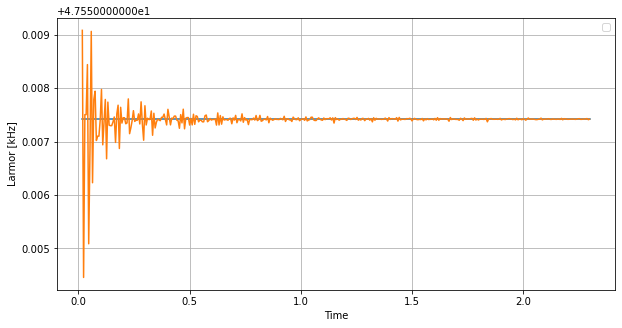

In [14]:


# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(t[3:len(yh)], xs[3:len(yh), 2]*T2*1000)
plt.plot(t_meas[3:len(yh)], np.array(omega_LS)*T2*1000)
plt.xlabel('Time')
plt.ylabel('Larmor [kHz]')
plt.legend()
plt.grid()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


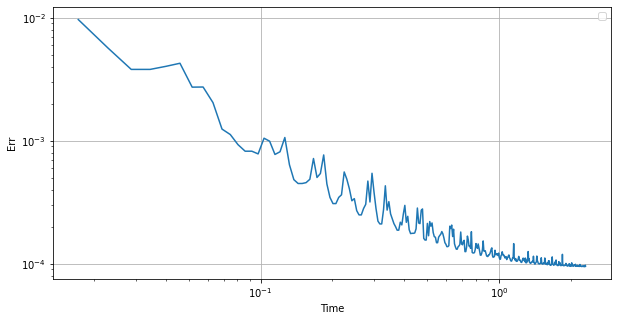

In [28]:
# Plot the results
plt.figure(figsize=(10, 5))
len_arr = len(t_meas[3:len(yh)])
plt.loglog(t_meas[3:len(yh)], omega_err)
# plt.loglog(t_meas[3:len(yh)],np.ones(len_arr)* np.sqrt(1/((N**2*g_D**2*T2**3)/(25.6*96.0))))
# plt.plot(t_meas[3:len(yh)], np.array(omega_LS)/100)
plt.xlabel('Time')
plt.ylabel('Err')
plt.legend()
plt.grid()
plt.show()